# Traning on prediciting z from x,y using kinect data

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

class KinectFolderDataset(Dataset):
    def __init__(self, folder_path, seq_length=30):
        self.X_seqs = []
        self.y_seqs = []
        self.seq_length = seq_length
        file_paths = glob.glob(os.path.join(folder_path, "*.csv"))
        
        for path in file_paths:
            df = pd.read_csv(path)
            all_cols = [c for c in df.columns if c != 'FrameNo']
            x_y_cols = sorted([c for c in all_cols if c.endswith('_x') or c.endswith('_y')])
            z_cols = sorted([c for c in all_cols if c.endswith('_z')])
            
            x_data = df[x_y_cols].values.astype(np.float32)
            y_data = df[z_cols].values.astype(np.float32)
            
            if len(df) >= seq_length:
                for i in range(len(df) - seq_length + 1):
                    self.X_seqs.append(x_data[i : i + seq_length])
                    self.y_seqs.append(y_data[i : i + seq_length])
            
    def __len__(self):
        return len(self.X_seqs)

    def __getitem__(self, idx):
        return torch.tensor(self.X_seqs[idx]), torch.tensor(self.y_seqs[idx])

class PoseLiftingModel(nn.Module):
    def __init__(self, input_size=26, hidden_size=128, num_layers=2, output_size=13, rnn_type='LSTM'):
        super(PoseLiftingModel, self).__init__()
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.relu(out)
        out = self.fc(out) 
        return out

In [24]:
# Initialize Dataset
folder = "../../data/kinect_good_preprocessed"
full_dataset = KinectFolderDataset(folder, seq_length=30)

# Create indices for the 10-sequence test set
indices = list(range(len(full_dataset)))
np.random.shuffle(indices)
test_indices = indices[:10]
train_val_indices = indices[10:]

# Create subsets
train_val_subset = Subset(full_dataset, train_val_indices)
test_subset = Subset(full_dataset, test_indices)

# Split train_val into Train (80%) and Validation (20%)
train_size = int(0.8 * len(train_val_subset))
val_size = len(train_val_subset) - train_size
train_data, val_data = random_split(train_val_subset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)

In [25]:
model = PoseLiftingModel(input_size=26, hidden_size=128, output_size=13, rnn_type='LSTM')
criterion = nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Initialize history
history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
patience = 5
best_val_loss = float('inf')
counter = 0

for epoch in range(50):
    model.train()
    train_running_loss = 0.0
    train_running_mae = 0.0
    
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        
        # Optimization is done on MSE
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_running_loss += loss.item()
        # Track MAE for quality judging
        train_running_mae += torch.mean(torch.abs(outputs - targets)).item()
    
    model.eval()
    val_running_loss = 0.0
    val_running_mae = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs)
            v_loss = criterion(outputs, targets)
            val_running_loss += v_loss.item()
            val_running_mae += torch.mean(torch.abs(outputs - targets)).item()
            
    # Calculate averages for the epoch
    avg_train_loss = train_running_loss / len(train_loader)
    avg_val_loss = val_running_loss / len(val_loader)
    avg_train_mae = train_running_mae / len(train_loader)
    avg_val_mae = val_running_mae / len(val_loader)
    
    # Store in history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_mae'].append(avg_train_mae)
    history['val_mae'].append(avg_val_mae)
    
    print(f"Epoch {epoch}: Train MSE {avg_train_loss:.6f}, Val MAE {avg_val_mae:.6f}")

    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 0: Train MSE 0.006367, Val MAE 0.050683
Epoch 1: Train MSE 0.003694, Val MAE 0.039884
Epoch 2: Train MSE 0.002548, Val MAE 0.033000
Epoch 3: Train MSE 0.001804, Val MAE 0.029131
Epoch 4: Train MSE 0.001303, Val MAE 0.024577
Epoch 5: Train MSE 0.001109, Val MAE 0.025527
Epoch 6: Train MSE 0.000937, Val MAE 0.021695
Epoch 7: Train MSE 0.000800, Val MAE 0.024880
Epoch 8: Train MSE 0.000760, Val MAE 0.017902
Epoch 9: Train MSE 0.000625, Val MAE 0.021207
Epoch 10: Train MSE 0.000585, Val MAE 0.016873
Epoch 11: Train MSE 0.000536, Val MAE 0.018287
Epoch 12: Train MSE 0.000487, Val MAE 0.015686
Epoch 13: Train MSE 0.000452, Val MAE 0.015390
Epoch 14: Train MSE 0.000447, Val MAE 0.013767
Epoch 15: Train MSE 0.000375, Val MAE 0.015688
Epoch 16: Train MSE 0.000369, Val MAE 0.013425
Epoch 17: Train MSE 0.000434, Val MAE 0.015817
Epoch 18: Train MSE 0.000317, Val MAE 0.014227
Epoch 19: Train MSE 0.000300, Val MAE 0.013180
Epoch 20: Train MSE 0.000280, Val MAE 0.013199
Epoch 21: Train MSE 0.0

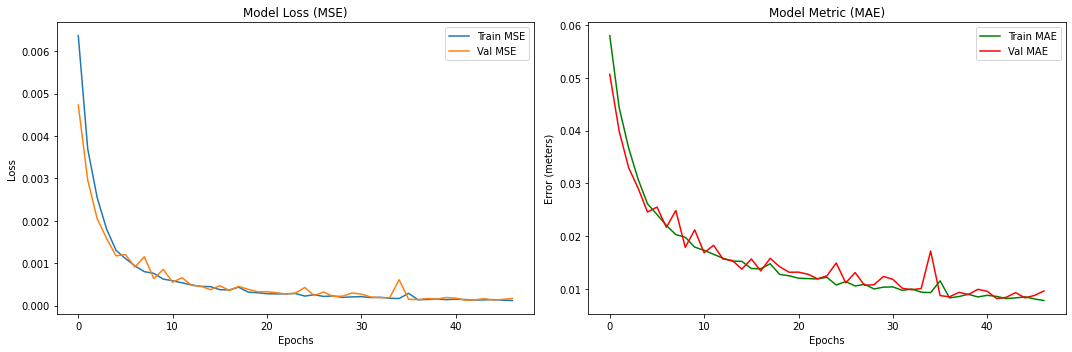

In [26]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: MSE (Log scale is often helpful if loss gets very small)
ax1.plot(history['train_loss'], label='Train MSE')
ax1.plot(history['val_loss'], label='Val MSE')
ax1.set_title('Model Loss (MSE)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Subplot 2: MAE (Physical Error)
ax2.plot(history['train_mae'], label='Train MAE', color='green')
ax2.plot(history['val_mae'], label='Val MAE', color='red')
ax2.set_title('Model Metric (MAE)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Error (meters)')
ax2.legend()

plt.tight_layout()
plt.show()

In [27]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Names of the 13 joints in order
joint_names = [
    "head", "left_shoulder", "left_elbow", "right_shoulder", "right_elbow",
    "left_hand", "right_hand", "left_hip", "right_hip", "left_knee", 
    "right_knee", "left_foot", "right_foot"
]

with torch.no_grad():
    # Take one sequence from the test loader
    inputs, targets = next(iter(test_loader)) 
    predictions = model(inputs)
    
    # Let's look at the very last frame of this sequence (frame 29)
    pred_frame = predictions[0, -1, :].numpy()
    target_frame = targets[0, -1, :].numpy()
    
    total_dist = 0
    print(f"{'Joint':<18} | {'Pred Z':<10} | {'True Z':<10} | {'Dist (cm)':<10}")
    print("-" * 60)
    
    for i in range(len(joint_names)):
        p_z = pred_frame[i]
        t_z = target_frame[i]
        # Distance is the absolute difference in Z (since X and Y are inputs)
        dist_cm = np.abs(p_z - t_z) * 100 
        total_dist += dist_cm
        
        print(f"{joint_names[i]:<18} | {p_z:8.3f} | {t_z:8.3f} | {dist_cm:8.3f} cm")
    
    print("-" * 60)
    print(f"Average distance: {total_dist / len(joint_names):.3f} cm")

Joint              | Pred Z     | True Z     | Dist (cm) 
------------------------------------------------------------
head               |    0.010 |    0.023 |    1.223 cm
left_shoulder      |   -0.127 |   -0.130 |    0.312 cm
left_elbow         |   -0.046 |   -0.045 |    0.089 cm
right_shoulder     |   -0.238 |   -0.227 |    1.112 cm
right_elbow        |   -0.009 |   -0.010 |    0.146 cm
left_hand          |   -0.150 |   -0.155 |    0.515 cm
right_hand         |    0.008 |    0.003 |    0.496 cm
left_hip           |   -0.034 |   -0.029 |    0.449 cm
right_hip          |   -0.023 |   -0.015 |    0.842 cm
left_knee          |   -0.146 |   -0.136 |    0.987 cm
right_knee         |   -0.000 |    0.004 |    0.445 cm
left_foot          |   -0.091 |   -0.090 |    0.086 cm
right_foot         |    0.051 |    0.049 |    0.165 cm
------------------------------------------------------------
Average distance: 0.528 cm
